In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, average_precision_score, precision_recall_curve, auc)
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Data Preprocessing

In [2]:
# ---------------------------------------------------------
# 1. Data Loading & Preprocessing
# ---------------------------------------------------------
# Loading data and converting dates to a proper weekly period format
df = pd.read_csv('Play Ringo (Master File).csv')
df['Created at'] = pd.to_datetime(df['Created at'], format='mixed', utc=True)
df['Week'] = df['Created at'].dt.to_period('W').dt.start_time

# Dropping 'Other' in ''Lineitem Type'
indexes_to_drop = df[df['Lineitem Type'] == 'Other'].index
df.drop(indexes_to_drop, inplace=True)

# Aggregate transaction data into a Weekly Sales Time Series
weekly_sales = df.groupby(['Week', 'Lineitem Type'])['Lineitem quantity'].sum().reset_index()
pivot_df = weekly_sales.pivot(index='Week', columns='Lineitem Type', values='Lineitem quantity').fillna(0)
df_processed = pivot_df.stack().reset_index()
df_processed.columns = ['Week', 'Lineitem Type', 'Quantity']

C:\Users\Isd\AppData\Local\Temp\ipykernel_27460\1029338591.py:5: DtypeWarning: Columns (46,53,57,67,69,71,72,77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Play Ringo (Master File).csv')
C:\Users\Isd\AppData\Local\Temp\ipykernel_27460\1029338591.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['Week'] = df['Created at'].dt.to_period('W').dt.start_time


In [3]:
df.shape

(10945, 81)

In [4]:
df_processed.isnull().sum()

Week             0
Lineitem Type    0
Quantity         0
dtype: int64

In [5]:
df_processed.Week.min()

Timestamp('2018-01-01 00:00:00')

In [6]:
df_processed.Week.max()

Timestamp('2025-12-01 00:00:00')

In [50]:
df_processed['Lineitem Type'].unique()	

array(['Accessories', 'Ash Grey Ringo', 'Cosmos Black Ringo',
       'Custom Ringo', 'Natural Maple Ringo', 'Red Ringo',
       'Scorekeeping Pegs'], dtype=object)

# Feature Engineering

In [7]:
# ---------------------------------------------------------
# 2. Feature Engineering
# ---------------------------------------------------------
df_processed = df_processed.sort_values(by=['Lineitem Type', 'Week'])

# Createing Lag Features: Past sales help predict future sales
df_processed['Qty_Week_0'] = df_processed['Quantity']  # Sales This Week
df_processed['Qty_Week_Minus_1'] = df_processed.groupby('Lineitem Type')['Quantity'].shift(1) # Sales 1 Week Ago
df_processed['Qty_Week_Minus_2'] = df_processed.groupby('Lineitem Type')['Quantity'].shift(2) # Sales 2 Weeks Ago
df_processed['Rolling_Mean_4'] = df_processed.groupby('Lineitem Type')['Quantity'].transform(lambda x: x.shift(1).rolling(4).mean()) # Avg of last 4 weeks

# Target: We want to predict if sales > 0 in the NEXT week (Shift -1)
df_processed['Target'] = (df_processed.groupby('Lineitem Type')['Quantity'].shift(-1) > 0).astype(int)

# Remove rows with NaN (first few weeks of lags) for training
df_model = df_processed.dropna().copy()

# Encode Product Type so the model understands "Red Ringo" vs "Blue Ringo"
le = LabelEncoder()
df_model['Type_Encoded'] = le.fit_transform(df_model['Lineitem Type'])

In [8]:
df_model.isna().sum()

Week                0
Lineitem Type       0
Quantity            0
Qty_Week_0          0
Qty_Week_Minus_1    0
Qty_Week_Minus_2    0
Rolling_Mean_4      0
Target              0
Type_Encoded        0
dtype: int64

In [9]:
df_model.head()

,Week,Lineitem Type,Quantity,Qty_Week_0,Qty_Week_Minus_1,Qty_Week_Minus_2,Rolling_Mean_4,Target,Type_Encoded
28,2018-05-07,Accessories,0.0,0.0,0.0,0.0,0.0,0,0
35,2018-05-14,Accessories,0.0,0.0,0.0,0.0,0.0,0,0
42,2018-06-25,Accessories,0.0,0.0,0.0,0.0,0.0,0,0
49,2018-07-30,Accessories,0.0,0.0,0.0,0.0,0.0,0,0
56,2018-08-06,Accessories,0.0,0.0,0.0,0.0,0.0,0,0


In [10]:
df_model.Target.unique()

array([0, 1])

In [11]:
df_model.shape

(2247, 9)

In [12]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2247 entries, 28 to 2274
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Week              2247 non-null   datetime64[ns]
 1   Lineitem Type     2247 non-null   object        
 2   Quantity          2247 non-null   float64       
 3   Qty_Week_0        2247 non-null   float64       
 4   Qty_Week_Minus_1  2247 non-null   float64       
 5   Qty_Week_Minus_2  2247 non-null   float64       
 6   Rolling_Mean_4    2247 non-null   float64       
 7   Target            2247 non-null   int32         
 8   Type_Encoded      2247 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(2), object(1)
memory usage: 158.0+ KB


# Defining Model

In [13]:
# ---------------------------------------------------------
# 3. Defining Model
# ---------------------------------------------------------
feature_cols = ['Qty_Week_0', 'Qty_Week_Minus_1', 'Qty_Week_Minus_2', 'Rolling_Mean_4', 'Type_Encoded']
X = df_model[feature_cols]
y = df_model['Target']


# Checking for Multi-Colinearity

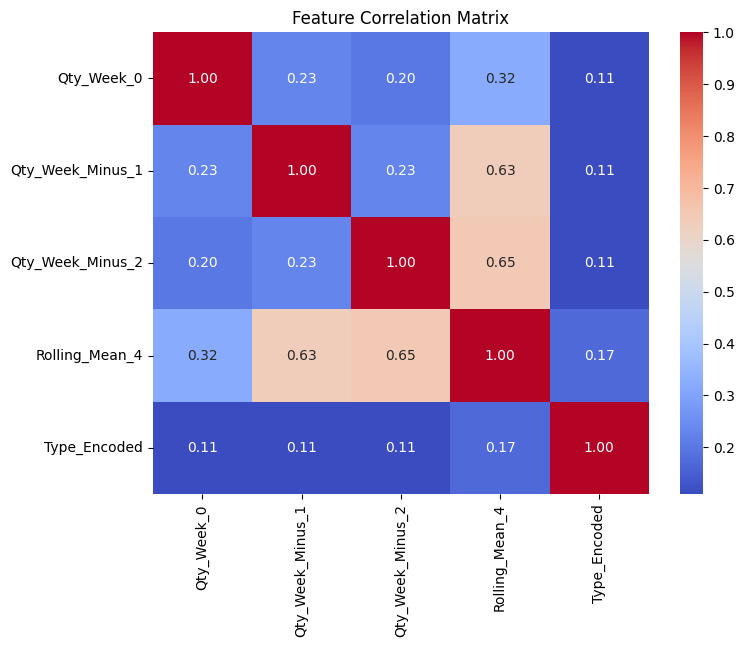


--- Variance Inflation Factor (VIF) ---
VIF > 5-10 indicates high multicollinearity.
            Feature       VIF
3    Rolling_Mean_4  3.748279
2  Qty_Week_Minus_2  2.066829
1  Qty_Week_Minus_1  1.993422
4      Type_Encoded  1.250996
0        Qty_Week_0  1.212444


In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ... [After defining X = df_model[feature_cols]] ...

# ---------------------------------------------------------
# CHECK FOR COLLINEARITY
# ---------------------------------------------------------

# 1. Visual Check: Correlation Matrix
plt.figure(figsize=(8, 6))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

# 2. Statistical Check: Variance Inflation Factor (VIF)
# VIF measures how much the behavior (variance) of an estimator is inflated due to multicollinearity.
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\n--- Variance Inflation Factor (VIF) ---")
print("VIF > 5-10 indicates high multicollinearity.")
print(vif_data.sort_values(by='VIF', ascending=False))

# Train-Test Split & Feature Scaling

In [15]:
# Split into Train (80%) and Test (20%) & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

# Scale features: Important for Logistic Regression to interpret coefficients correctly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

In [16]:
# Train
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Model Testing

In [17]:
# Predictions
y_pred = lr_model.predict(X_test_scaled)        # 0 or 1 labels
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1] # Probability score (0.0 to 1.0)

In [29]:
y_pred

array([1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,

In [32]:
y_prob

array([0.91251278, 0.29384906, 0.31632312, 0.27233569, 1.        ,
       0.31632312, 0.99603519, 0.93607364, 0.37542869, 0.98806601,
       0.29833656, 0.98523588, 0.52744711, 0.35324811, 0.55282591,
       0.85925766, 0.36041663, 0.42964791, 0.33968919, 0.49921095,
       0.29384906, 0.9743299 , 0.34279753, 0.57303473, 0.34275214,
       0.38874362, 0.74846492, 0.29384906, 0.47354084, 0.27233569,
       0.73765127, 0.9343592 , 0.44188685, 0.45200636, 0.39728685,
       0.79819201, 0.63813436, 0.33968919, 0.38747066, 0.60038974,
       0.33483928, 0.61085909, 0.98283714, 0.33661387, 0.47366484,
       0.5305337 , 0.32411872, 0.39367211, 0.29384906, 0.38874362,
       0.83237073, 0.33848329, 0.80066247, 0.39057576, 0.48735138,
       0.43677663, 0.33968919, 0.32905875, 0.29384906, 0.44889047,
       0.97866855, 0.34080017, 0.61531271, 0.30839669, 0.29672643,
       0.33968919, 0.96052489, 0.35464118, 0.37230635, 0.28505217,
       0.44391536, 0.94742897, 0.51386678, 0.29384906, 0.43098

# Model Evaluation Metrics

In [18]:
# ---------------------------------------------------------
# 2. Calculate Evaluation Metrics
# ---------------------------------------------------------
print("--- Detailed Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUC-PR:    {average_precision_score(y_test, y_prob):.4f}")

--- Detailed Evaluation Metrics ---
Accuracy:  0.7467
Precision: 0.7907
Recall:    0.5397
F1 Score:  0.6415
AUC-ROC:   0.7911
AUC-PR:    0.7779


In [19]:
evaluation_metrics_df = pd.DataFrame([{
    "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
    "Precision": round(precision_score(y_test, y_pred), 4),
    "Recall":    round(recall_score(y_test, y_pred), 4),
    "F1 Score":  round(f1_score(y_test, y_pred), 4),
    "AUC-ROC":   round(roc_auc_score(y_test, y_prob), 4),
    "AUC-PR":    round(average_precision_score(y_test, y_prob), 4)
}])

### **Evaluation Metrics**

#### **Key Metrics**

* **Accuracy (75%):** A solid baseline. The model is correct 3 out of 4 times.
* **Precision (79%):** **High Trust.** If the model tells you "Scorekeeping Pegs will sell," you can be ~80% sure it's true. It rarely gives false alarms.
* **Recall (54%):** **Missed Opportunities.** The model only captures about half of the total sales. It ignores "maybe" cases to preserve its high precision.
* **F1 (64%):** **Good, but Cautious**  An F1 Score of 0.6415 (64%) tells us that your model is "Good, but Cautious." Which means Your F1 score (64%) is being "dragged down" by your Recall (54%). The model is sacrificing coverage to ensure accuracy. It would rather stay silent than risk giving you a False Alarm.
* **AUC-ROC (0.79):** **Very Good.** This score (close to 0.8) means the model is excellent at ranking products. Even if it doesn't predict a "Sale" outright, it consistently ranks selling products higher than non-selling ones.
* **AUC-PR (0.78):** **Strong/Good.** A score of 0.78 (78%) is strong/good. It means your model is reliable. It successfully finds most of the sales opportunities (Recall) while keeping false alarms low (Precision).


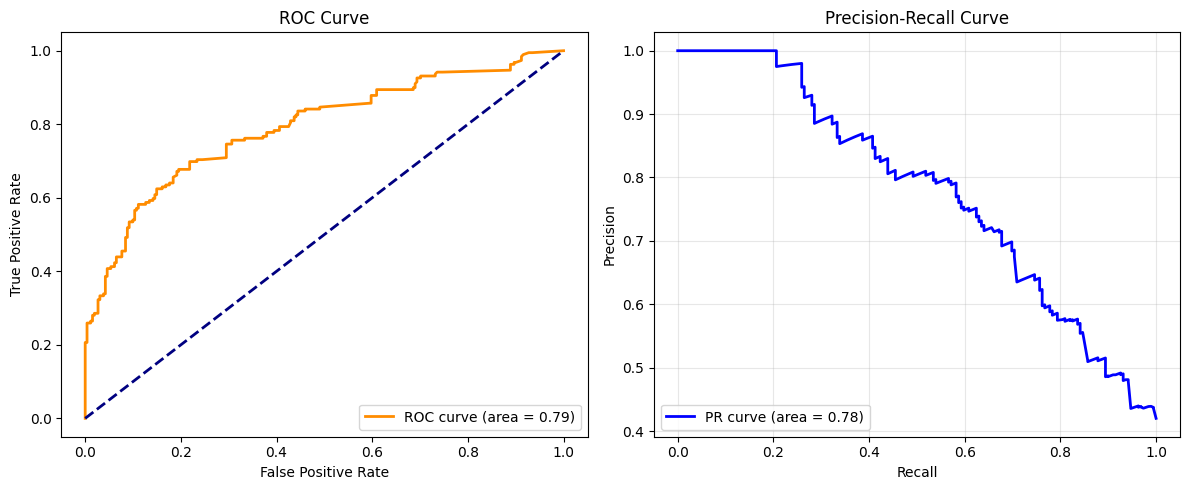

In [20]:
# ---------------------------------------------------------
# 3. Visualize Curves
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# Plot Precision-Recall Curve
precision_c, recall_c, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_c, precision_c)
plt.subplot(1, 2, 2)
plt.plot(recall_c, precision_c, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- **Left (ROC Curve):** Shows the trade-off between True Positive Rate (catching sales) and False Positive Rate (false alarms). The curve hugging the top-left corner is good.

- **Right (Precision-Recall Curve):** Shows the trade-off between Precision and Recall. High area under this curve indicates the model is reliable even if sales are rare events.


**ROC & Precision-Recall Curves Interpretations**

**ROC Curve (Left):**

- **Shape:** You will see the orange line arching up towards the top-left corner.

- **Meaning**: The area under this curve is 0.79. This confirms the model is robust. It is not guessing randomly (which would be the straight diagonal line). It successfully separates "Winners" from "Losers."

**Precision-Recall Curve (Right):**

- **Shape:** You likely see a line that starts high (1.0) and stays high for a bit, then drops as Recall increases.

- **Meaning**: This curve visualizes the trade-off. To get higher Recall (catch those 87 missed sales), you would have to accept lower Precision (more false alarms). The Area (0.78) is strong, suggesting you can afford to lower the threshold to catch more sales without destroying accuracy.

# Confusion Matrix

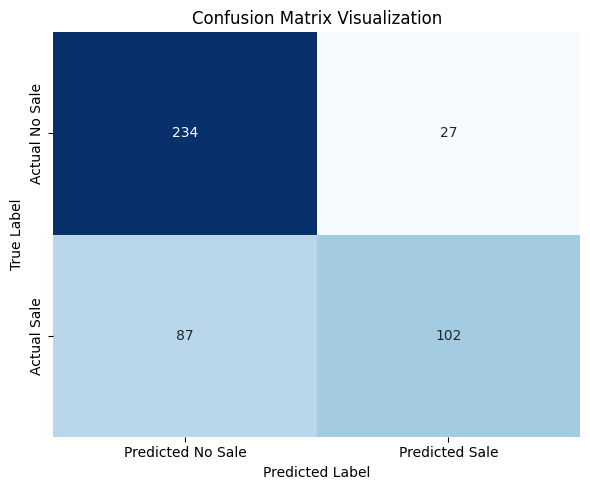

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred are already defined from the previous model step
# y_test: Actual values
# y_pred: Predicted values by the model

# 1. Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Sale', 'Predicted Sale'],
            yticklabels=['Actual No Sale', 'Actual Sale'])

# 3. Add Labels and Title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualization')

# 4. Display
plt.tight_layout()
plt.show() # Use plt.savefig('filename.png') if saving to a file

In [22]:
print(cm)

[[234  27]
 [ 87 102]]


#### **Confusion Matrix Analysis**

* **True Negatives (234):** The model correctly identified 234 instances where products would *not* sell. This is good for inventory management (avoiding overstock).
* **True Positives (102):** The model correctly caught 102 sales opportunities.
* **False Positives (27):** Only 27 times did it say "It will sell" when it didn't. This is very low.
* **False Negatives (87):** The model missed 87 actual sales. This is the model's main weakness; it is too cautious.

How to Interpret the Plot:

- **Top-Left (True Negatives):** The model correctly predicted "No Sale". (High numbers here mean you aren't wasting marketing on dead products).

- **Bottom-Right (True Positives):** The model correctly predicted a "Sale". (High numbers here mean you are capturing the sales opportunities).

- **Top-Right (False Positives):** Predicted "Sale" but actually "No Sale". (Type I Error).

- **Bottom-Left (False Negatives):** Predicted "No Sale" but actually "Sale". (Type II Error - Missed Opportunity).

# Feature Importance (Coefficients Comparison)

In [23]:
# 2. Calculate Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

# Calculate Odds Ratio: e^(Coefficient)
importance_df['Odds_Ratio'] = np.exp(importance_df['Coefficient'])

# Sort for viewing
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

print("--- Feature Importance ---")
print(importance_df[['Feature', 'Coefficient', 'Odds_Ratio']])

--- Feature Importance ---
            Feature  Coefficient  Odds_Ratio
1  Qty_Week_Minus_1     2.253627    9.522207
3    Rolling_Mean_4     0.795385    2.215294
2  Qty_Week_Minus_2     0.512102    1.668796
0        Qty_Week_0     0.311035    1.364838
4      Type_Encoded     0.211270    1.235246


### **General Concepts: What do these numbers mean?**

#### **A. Coefficient (Log-Odds)**

* **What it is:** The raw mathematical weight inside the model equation.
* **What it tells us:**
* **Positive (+):** Increases the chance of a sale.
* **Negative (-):** Decreases the chance of a sale.
* **Zero (0):** No effect.


* **The Problem:** It is measured in "Log-Odds," which is very hard for humans to understand intuitively (e.g., "The log-odds increased by 2.25" doesn't mean much to a manager).

#### **B. Odds Ratio (The "Multiplier")**

* **What it is:** The exponential of the coefficient (). This converts the math into a real-world **Multiplier**.
* **What it tells us:** "For every 1 unit increase in X, the odds of selling multiply by Y."
* **> 1.0:** Positive effect (Likelihood goes UP).
* **< 1.0:** Negative effect (Likelihood goes DOWN).
* **= 1.0:** No effect (Neutral).


* **Why we use it:** It lets you say: *"If sales double, the chance of selling next week goes up by 5 times."*

---

### **Interpretation of Features**

#### **1. `Qty_Week_Minus_1` (Sales 1 Week Ago)**

* **Coefficient (2.25):** Very strong positive number. This is the main driver.
* **Odds Ratio (9.52):** **The "Hot Hand" Effect.**
* **Interpretation:** This is massive. Since your data was standardized (scaled), this means that if sales last week were **1 Standard Deviation higher than average**, the odds of making a sale *next week* increase by **9.5 times**.
* **Business Meaning:** Momentum is everything. If a product sold last week, it is almost guaranteed to sell again. If it didn't, it's very likely to stay dead.

#### **2. `Rolling_Mean_4` (Average Sales of Last 4 Weeks)**

* **Coefficient (0.80):** Moderate positive influence.
* **Odds Ratio (2.22):** **The "Trend" Effect.**
* **Interpretation:** If the *average* monthly sales increase by 1 Standard Deviation, the odds of a future sale **more than double (2.2x)**.
* **Business Meaning:** This captures the "Baseline Health" of the product. Even if last week was quiet, a strong monthly average keeps the probability alive.

#### **3. `Qty_Week_Minus_2` (Sales 2 Weeks Ago)**

* **Coefficient (0.51):** Weaker positive influence.
* **Odds Ratio (1.67):** **The "Fading Memory" Effect.**
* **Interpretation:** Sales from two weeks ago still help (increasing odds by **1.67x**), but they are far less important than sales from one week ago (9.5x).
* **Business Meaning:** The relevance of sales data decays quickly. What happened 14 days ago matters, but not nearly as much as what happened 7 days ago.

#### **4. `Qty_Week_0` (Current Week Sales)**

* **Coefficient (0.31):** Weak positive influence.
* **Odds Ratio (1.36):** **The "Immediate" Effect.**
* **Interpretation:** Knowing the current partial week's sales only increases the odds by **1.36x**.
* **Business Meaning:** This is surprisingly low. It suggests that *completed* historical weeks (Lag 1) are more reliable predictors than the *in-progress* current week. The model prefers finished patterns over real-time noise.

#### **5. `Type_Encoded` (Product Name)**

* **Coefficient (0.21):** Very weak positive influence.
* **Odds Ratio (1.24):** **The "Identity" Effect.**
* **Interpretation:** The odds ratio is near 1.0 (Neutral).
* **Business Meaning:** The specific product ID (e.g., whether it's "Red Ringo" or "Blue Ringo") matters very little compared to its actual sales performance.
* **Why this is good:** It means your model is **universal**. It doesn't just memorize that "Red Ringo sells." It learns that "Anything with momentum sells," regardless of what the product is named.

C:\Users\Isd\AppData\Local\Temp\ipykernel_27460\3067943650.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='viridis')
C:\Users\Isd\AppData\Local\Temp\ipykernel_27460\3067943650.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Odds_Ratio', y='Feature', data=importance_df, palette='viridis')
C:\Users\Isd\AppData\Local\Temp\ipykernel_27460\3067943650.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


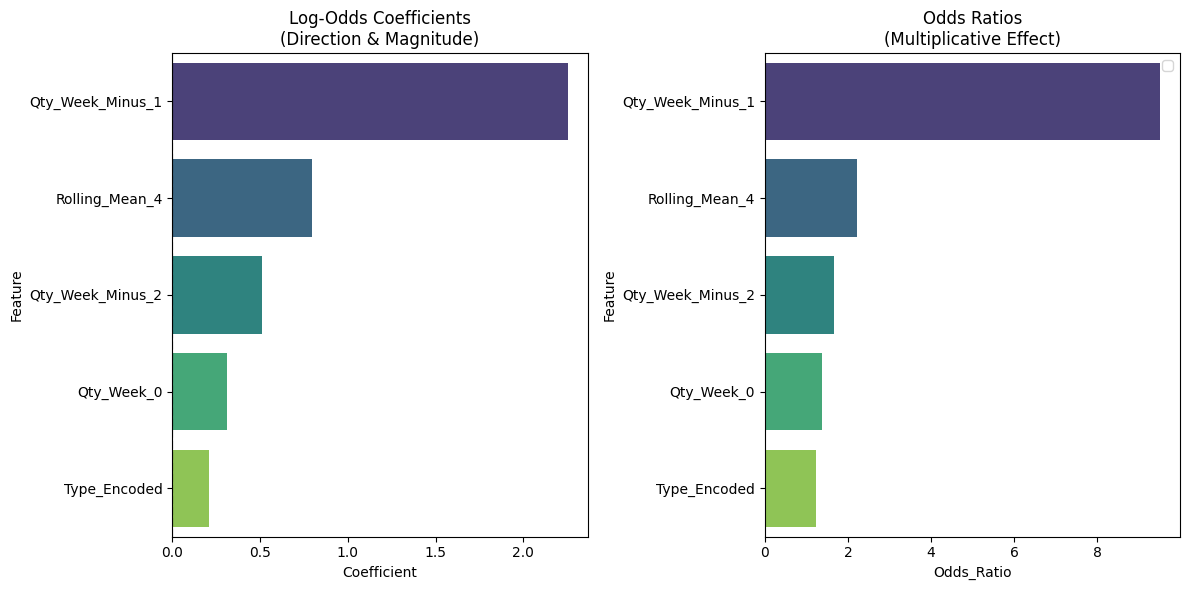

In [51]:
# 3. Visualization
plt.figure(figsize=(12, 6))

# Plot Coefficients
plt.subplot(1, 2, 1)
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='viridis')
plt.axvline(0, color='black', linestyle='--')
plt.title('Log-Odds Coefficients\n(Direction & Magnitude)')

# Plot Odds Ratios
plt.subplot(1, 2, 2)
sns.barplot(x='Odds_Ratio', y='Feature', data=importance_df, palette='viridis')
plt.title('Odds Ratios\n(Multiplicative Effect)')
plt.legend()

plt.tight_layout()

Raw Coefficients (Log-Odds) and the Odds Ratios, which are easier to interpret.

**Interpretation of the Results**

- **_Qty_Week_Minus_1 (Sales 1 Week Ago):_**

  -  _Coefficient (1.60):_ Positive and strong.

  - _Odds Ratio (4.95):_ This is huge. Because the data was scaled (Standardized), this means for every 1 Standard Deviation increase in last week's sales, the odds of selling next week increase by a factor of ~5x.

- **_Rolling_Mean_4:_** (Avg Sales Last 4 Weeks):

   - _Odds Ratio (3.03):_ A strong 4-week trend increases the odds of a sale by ~3x.

- **_Qty_Week_0:_** (Current Week):

   - Odds Ratio (1.58): Still positive, but less predictive than the lag features. This suggests the trend (past history) is more important than the immediate "now" for predicting the next step.

- **_Type_Encoded:_**

    - Odds Ratio (1.06): Near 1.0 means "Neutral". The specific product ID number (alphabetical order) doesn't carry much weight, which is expected and good (the model relies on sales history, not just the product name).

# Forcasting

In [25]:
# ---------------------------------------------------------
# 6. Forecasting (Predicting the Unknown Future)
# ---------------------------------------------------------
# Get the LATEST available week for each product (The "Now")
last_week_data = df_processed.groupby('Lineitem Type').tail(1).copy().fillna(0)
last_week_data['Type_Encoded'] = le.transform(last_week_data['Lineitem Type'])

# --- NEW CODE: Calculate the Date ---
# Find the last week in your history
last_historical_week = last_week_data['Week'].max()
# Add 7 days to get the "Next Week" you are predicting for
forecast_target_date = last_historical_week + pd.Timedelta(weeks=1)
# ------------------------------------

# Prepare features for the future
X_future = last_week_data[feature_cols]
X_future_scaled = scaler.transform(X_future)

# Predict probability of sale for NEXT week
future_probs = lr_model.predict_proba(X_future_scaled)[:, 1]
last_week_data['Forecast_Prob_Sale'] = future_probs

print(f"\n--- Future Forecast (Week of {forecast_target_date.date()}) ---")
print(last_week_data[['Lineitem Type', 'Forecast_Prob_Sale']].sort_values(by='Forecast_Prob_Sale', ascending=False).head())


--- Future Forecast (Week of 2025-12-08) ---
            Lineitem Type  Forecast_Prob_Sale
2274    Scorekeeping Pegs            0.422934
2273            Red Ringo            0.388744
2269       Ash Grey Ringo            0.382153
2272  Natural Maple Ringo            0.363863
2271         Custom Ringo            0.339689


### **Forecast Interpretation (Next Week)**

The forecast table shows probabilities for next week:

| Product | Probability | Decision (at 0.5 Threshold) |
| --- | --- | --- |
| **Scorekeeping Pegs** | **42%** | **No Sale** |
| **Red Ringo** | **39%** | **No Sale** |
| **Ash Grey Ringo** | **38%** | **No Sale** |

**Critical Insight:**
Notice that **ALL** your top probabilities are **below 50% (0.5)**.

* If you use the default decision threshold of 0.5, the model predicts **ZERO sales** for next week.
* **Why?** Because the model is conservative (as seen in the Recall score). It sees "potential" (38-42%), but not "certainty."
* **Action:** To use this forecast effectively, you must **lower your threshold to ~0.35**. This will flag "Scorekeeping Pegs" and "Red Ringo" as targets for marketing "nudges."

---

# The Forecast Visualization

C:\Users\Isd\AppData\Local\Temp\ipykernel_27460\4010532998.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Forecast_Prob_Sale', y='Lineitem Type', data=plot_data, palette='viridis')


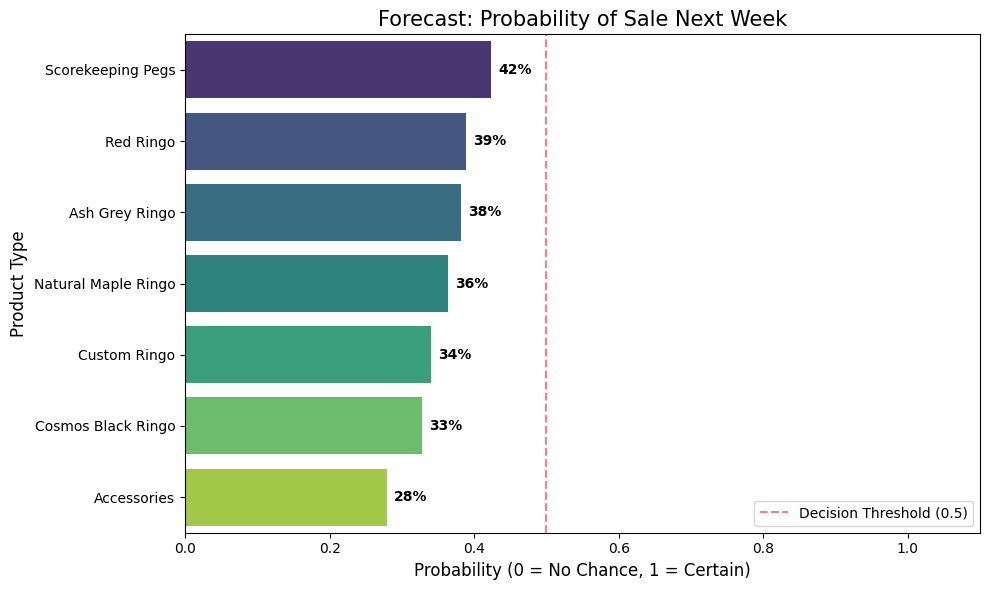

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'last_week_data' is already created from the forecasting step

# 1. Sort data for better visualization (Highest Probability on top)
plot_data = last_week_data.sort_values(by='Forecast_Prob_Sale', ascending=False)

# 2. Setup Plot
plt.figure(figsize=(10, 6))

# 3. Create Bar Chart
sns.barplot(x='Forecast_Prob_Sale', y='Lineitem Type', data=plot_data, palette='viridis')

# 4. Styling
plt.title('Forecast: Probability of Sale Next Week', fontsize=15)
plt.xlabel('Probability (0 = No Chance, 1 = Certain)', fontsize=12)
plt.ylabel('Product Type', fontsize=12)
plt.xlim(0, 1.1)  # Set x-axis limit slightly above 1 for label space
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Decision Threshold (0.5)') # Optional Reference Line
plt.legend(loc='lower right')

# 5. Add Value Labels to Bars
for index, value in enumerate(plot_data['Forecast_Prob_Sale']):
    plt.text(value + 0.01, index, f'{value:.0%}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show() # Use plt.savefig('forecast_plot.png') to save

#  Changing Decision Threshold

C:\Users\Isd\AppData\Local\Temp\ipykernel_27460\709521187.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Forecast_Prob_Sale', y='Lineitem Type', data=plot_data, palette=bar_colors)


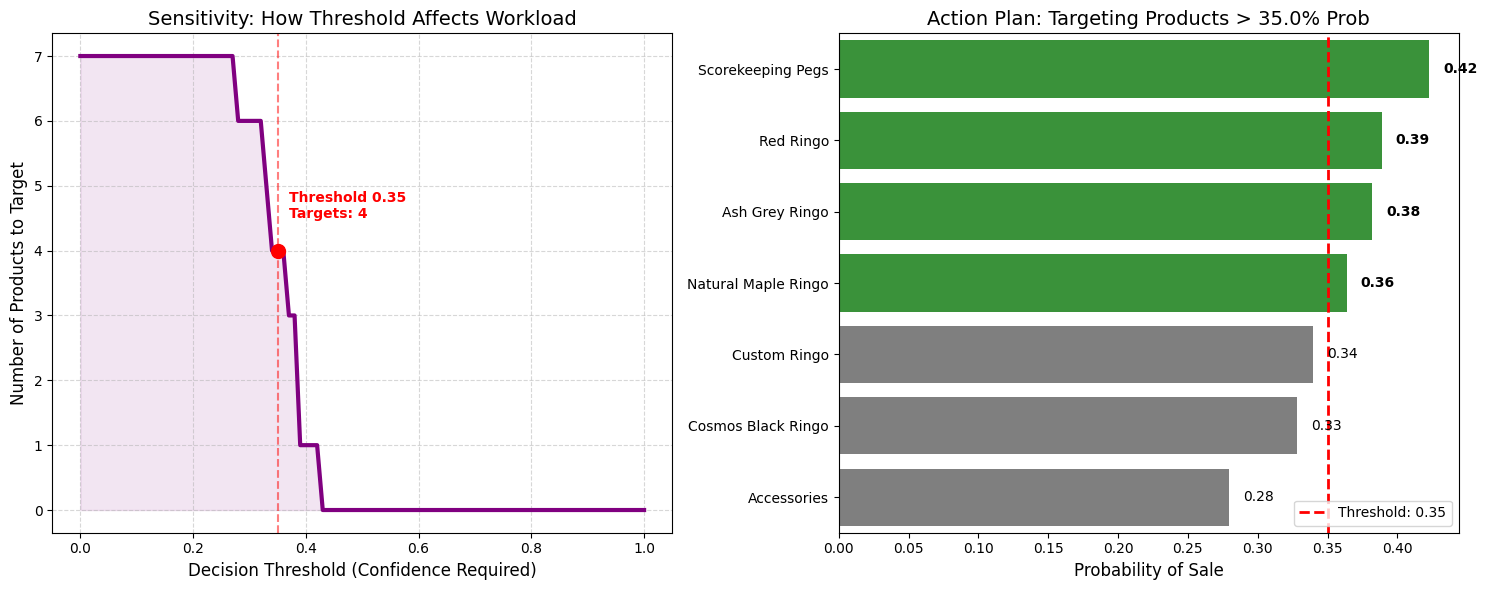

In [46]:
# ... (Assuming 'last_week_data' is ready from previous steps) ...

# 1. Setup Data
CUSTOM_THRESHOLD = 0.35  # The threshold we want to visualize

# Prepare Sensitivity Data (Loop through 0% to 100%)
thresholds = np.linspace(0, 1, 101)
target_counts = [(last_week_data['Forecast_Prob_Sale'] >= t).sum() for t in thresholds]

# Prepare Bar Chart Data
plot_data = last_week_data.sort_values(by='Forecast_Prob_Sale', ascending=False)
# Create a color list: Green for Targets, Gray for Others
bar_colors = ['#2ca02c' if x >= CUSTOM_THRESHOLD else '#7f7f7f' for x in plot_data['Forecast_Prob_Sale']]

# 2. Create Visualization
plt.figure(figsize=(15, 6))

# --- Plot 1: Sensitivity Curve ---
plt.subplot(1, 2, 1)
plt.plot(thresholds, target_counts, color='purple', linewidth=3)
plt.fill_between(thresholds, target_counts, color='purple', alpha=0.1)

# Highlight our chosen point
current_target_count = (last_week_data['Forecast_Prob_Sale'] >= CUSTOM_THRESHOLD).sum()
plt.plot(CUSTOM_THRESHOLD, current_target_count, 'ro', markersize=10, zorder=5)
plt.axvline(CUSTOM_THRESHOLD, color='red', linestyle='--', alpha=0.5)
plt.text(CUSTOM_THRESHOLD + 0.02, current_target_count + 0.5, 
         f'Threshold {CUSTOM_THRESHOLD}\nTargets: {current_target_count}', color='red', fontweight='bold')

plt.title('Sensitivity: How Threshold Affects Workload', fontsize=14)
plt.xlabel('Decision Threshold (Confidence Required)', fontsize=12)
plt.ylabel('Number of Products to Target', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)


# --- Plot 2: The "Cutoff" Bar Chart ---
plt.subplot(1, 2, 2)
sns.barplot(x='Forecast_Prob_Sale', y='Lineitem Type', data=plot_data, palette=bar_colors)
plt.axvline(CUSTOM_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold: {CUSTOM_THRESHOLD}')

plt.title(f'Action Plan: Targeting Products > {CUSTOM_THRESHOLD*100}% Prob', fontsize=14)
plt.xlabel('Probability of Sale', fontsize=12)
plt.ylabel('')
plt.legend(loc='lower right')

# Add values next to bars
for i, v in enumerate(plot_data['Forecast_Prob_Sale']):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center', fontweight='bold' if v >= CUSTOM_THRESHOLD else 'normal')

plt.tight_layout()
plt.show()

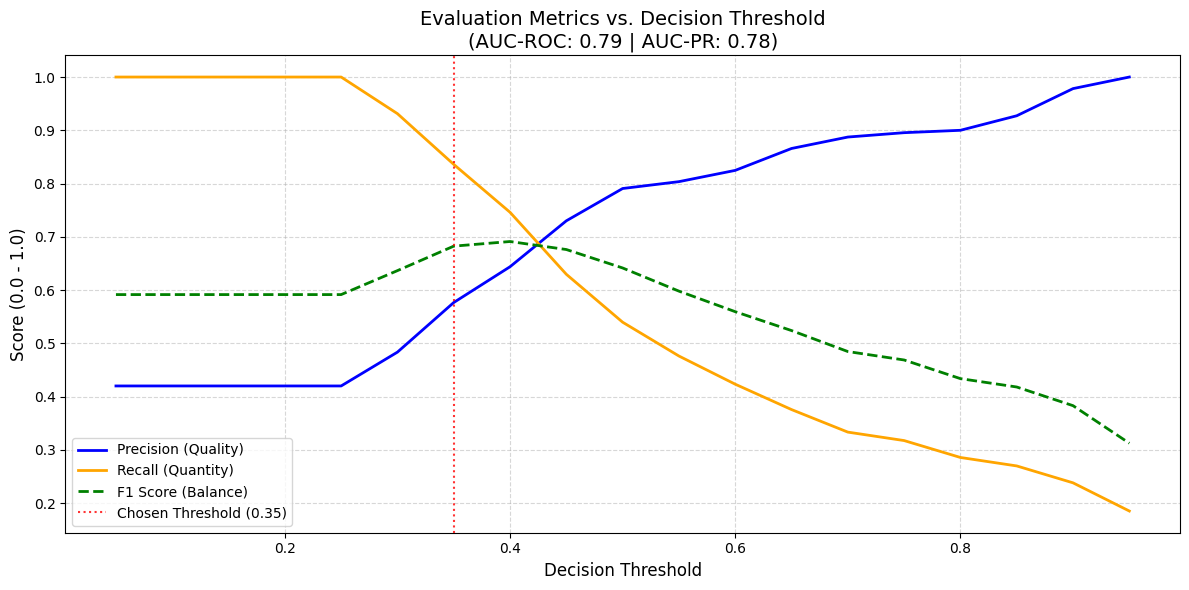


--- Impact of Threshold on Metrics ---
 Threshold  Precision  Recall  F1_Score
      0.20      0.420   1.000     0.592
      0.25      0.420   1.000     0.592
      0.30      0.484   0.931     0.637
      0.35      0.577   0.836     0.683
      0.40      0.644   0.746     0.691
      0.45      0.730   0.630     0.676
      0.50      0.791   0.540     0.642
      0.55      0.804   0.476     0.598
      0.60      0.825   0.423     0.559


In [47]:
# =========================================================
# 7. METRIC SENSITIVITY ANALYSIS (FIXED)
# =========================================================

# --- STEP 1: Ensure Predictions exist (The Fix) ---
# We re-calculate these just in case they were lost or not defined yet
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
# We also need y_test, which should already exist from the train_test_split step

# --- STEP 2: Run the Analysis ---

# A. Define Thresholds to Test (from 0.05 to 0.95)
threshold_list = np.linspace(0.05, 0.95, 19)
metrics_data = []

# B. Calculate AUC scores (Constant regardless of threshold)
auc_roc = roc_auc_score(y_test, y_pred_proba)
auc_pr = average_precision_score(y_test, y_pred_proba)

# C. Loop through thresholds to calculate changing metrics
for t in threshold_list:
    # Convert probabilities to 1 or 0 based on current threshold 't'
    y_pred_t = (y_pred_proba >= t).astype(int)
    
    # Calculate scores
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    
    metrics_data.append([t, prec, rec, f1])

# Create DataFrame for easy viewing
df_metrics = pd.DataFrame(metrics_data, columns=['Threshold', 'Precision', 'Recall', 'F1_Score'])

# D. VISUALIZATION
plt.figure(figsize=(12, 6))

# Plot Precision, Recall, and F1
plt.plot(df_metrics['Threshold'], df_metrics['Precision'], label='Precision (Quality)', color='blue', linewidth=2)
plt.plot(df_metrics['Threshold'], df_metrics['Recall'], label='Recall (Quantity)', color='orange', linewidth=2)
plt.plot(df_metrics['Threshold'], df_metrics['F1_Score'], label='F1 Score (Balance)', color='green', linestyle='--', linewidth=2)

# Mark the Custom Threshold
MY_THRESHOLD = 0.35  # <--- Matches your strategy
plt.axvline(MY_THRESHOLD, color='red', linestyle=':', alpha=0.8, label=f'Chosen Threshold ({MY_THRESHOLD})')

# Add Titles and Labels
plt.title(f'Evaluation Metrics vs. Decision Threshold\n(AUC-ROC: {auc_roc:.2f} | AUC-PR: {auc_pr:.2f})', fontsize=14)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()

# E. PRINT DATA TABLE (Focusing on the relevant range)
print("\n--- Impact of Threshold on Metrics ---")
print(df_metrics[(df_metrics['Threshold'] >= 0.2) & (df_metrics['Threshold'] <= 0.6)].round(3).to_string(index=False))

### **How to Interpret the Result**

1. **The "X" Shape:** You will see the Blue Line (Precision) go **UP** as you move right, and the Orange Line (Recall) go **DOWN**.
* This visualizes the trade-off: The stricter you are, the fewer false alarms you get (Precision), but the more sales you miss (Recall).


2. **The Green Arch (F1):** The peak of the green dotted line is technically the "mathematically optimal" threshold.
3. **Your Red Line (0.35):** Look at where your red vertical line intersects the Orange (Recall) line. This tells you exactly what percentage of sales you are capturing with your new strategy.

**Note on AUC:**

* **AUC-ROC** and **AUC-PR** are single scores that describe the *entire* curve. They do not change when you move the threshold (they describe the path itself, not a point on it), which is why they are displayed in the title as constant values.